# VARIFORC variable smoothing

A single smoothing window is a compromise whenever a FORC diagram carries features on
different scales at once, which is the normal case: a narrow ridge sitting on a broad,
low-amplitude background. Resolve the ridge and the background is noise; clean the
background and the ridge is smeared.

The variable-smoothing protocol of
[Egli (2013)](https://doi.org/10.1016/j.gloplacha.2013.08.003) removes the compromise. It
lets the regression window grow with distance from the origin of the diagram, where
Preisach-type FORC functions genuinely are smoother, while holding it narrow across the
features that need resolving. `pmagpy.forc` implements it, together with the per-cell
error analysis of [Heslop and Roberts (2012)](https://doi.org/10.1029/2012GC004115).

This notebook leads with the workflow and then works through it:

1. **The workflow**: variable smoothing on a magnetofossil sample in one call.
2. **What changes and why**: conventional versus variable smoothing side by side.
3. **How the window varies** across the diagram.
4. **Significance**: which parts of a diagram the data actually support.
5. **Choosing parameters** for your own sample.
6. **Diagonal artefacts** and how they are suppressed.
7. **Fidelity**: how the implementation is checked against the published algorithm.

It builds on [FORC_processing.ipynb](./FORC_processing.ipynb) for reading, drift
correction and archiving, and on [FORC_smoothing.ipynb](./FORC_smoothing.ipynb) for the
mechanics of local-regression smoothing.

> **Example data.** The measurements used here are redistributed from the example
> datasets that accompany the VARIFORC package, with thanks to Ramon Egli. See
> [`SOURCE.md`](../example_data/FORC/variforc_examples/SOURCE.md) for provenance and
> licensing. The implementation in `pmagpy.forc` is independent, written from the
> published equations rather than from the VARIFORC source.

## Install and import packages

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import pmagpy.forc as forc

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

print(f"compiled fast path available: {forc.numba_available()}")

compiled fast path available: True


## 1. The workflow

The sample is a magnetofossil-bearing pelagic carbonate from the Eastern Equatorial
Pacific: 450 reversal curves at 0.5 mT on an alternating gradient magnetometer. Its
diagnostic feature is a **central ridge** — a horizontal ridge along B<sub>u</sub> = 0
that is the signature of non-interacting single-domain particles
([Egli et al., 2010](https://doi.org/10.1029/2009GC002916)). A central ridge is
intrinsically narrow in B<sub>u</sub>, so it is exactly the feature that oversmoothing
destroys.

`variforc_settings` describes the sample by what its diagram shows rather than by
smoothing factors. Here: a central ridge, sitting a few tenths of a millitesla above the
axis, on a background that can take a much larger window.

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


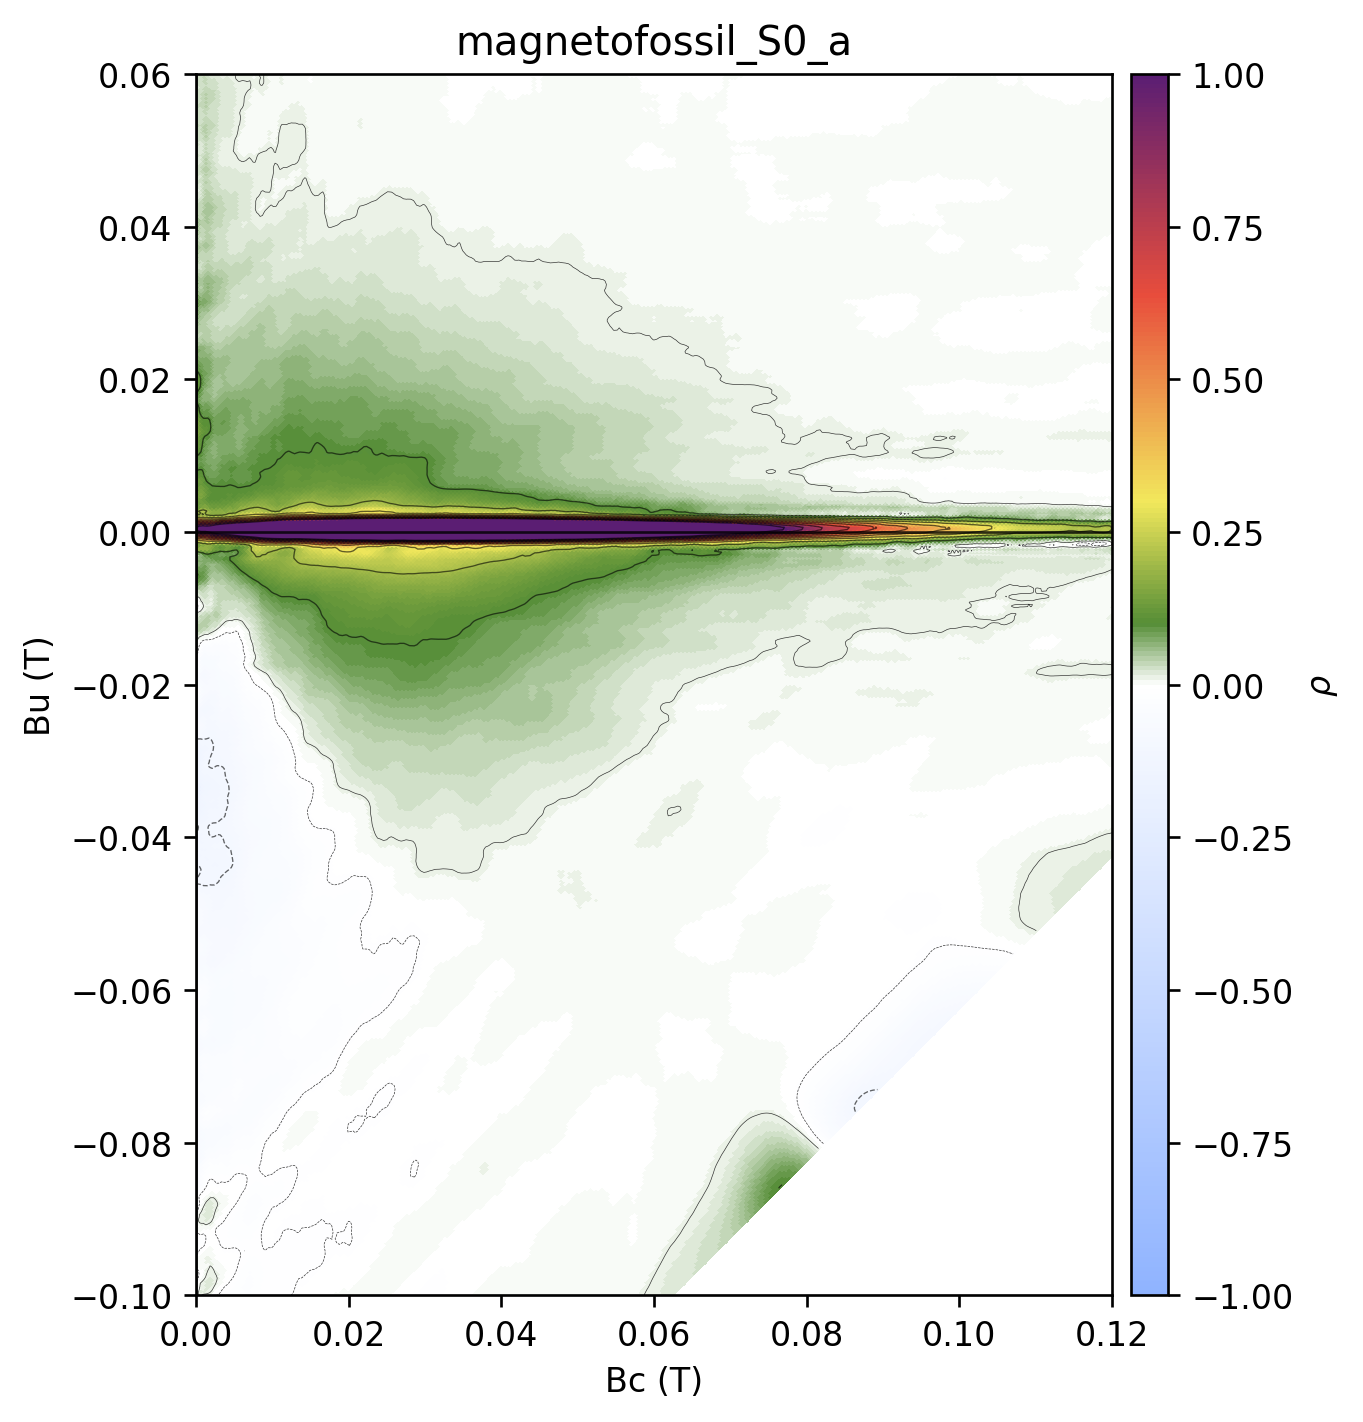

In [2]:
data = '../example_data/FORC/variforc_examples/magnetofossil_S0_a.txt'

settings = forc.variforc_settings(
    'central_ridge',              # what the diagram shows
    smoothing_factor=9,           # baseline window away from the ridge
    growth_rate=0.1,              # how fast it grows with distance
    central_ridge=4,              # window held this narrow across the ridge
    central_ridge_position=0.0004,  # the ridge sits 0.4 mT above Bu = 0
)

out = forc.process_forc(
    mode='i', path=data,
    do_regrid=True, B_step=0.0005,
    smoothing='variforc', variforc=settings,
    Bu_min=-0.10, Bu_max=0.06, Bc_max=0.12,
    color_scale_version=2, plot_hyst=False, verbose=False,
)

The central ridge is resolved sharply while the background is smooth enough to
contour. Everything used is recorded with the result.

In [3]:
params = out['smoothing_params']
print(f"method            : {params['method']} (preset {params['preset']!r})")
print(f"baseline factor   : s1 = {params['sc1']:g}, growth rate lambda = "
      f"{params['lambda_c']:g}")
print(f"ridge floor       : s_b0 = {params['sb0']:g}")
print(f"calibration points: {out['n_calibration_points']}, "
      f"drift corrected: {out['drift_corrected']}")

method            : variforc (preset 'central_ridge')
baseline factor   : s1 = 9, growth rate lambda = 0.1
ridge floor       : s_b0 = 4
calibration points: 450, drift corrected: True


## 2. What changes, and why

The clearest way to see what variable smoothing buys is to put it beside conventional
processing at two fixed smoothing factors: one small enough to resolve the ridge, and one
large enough to clean the background.

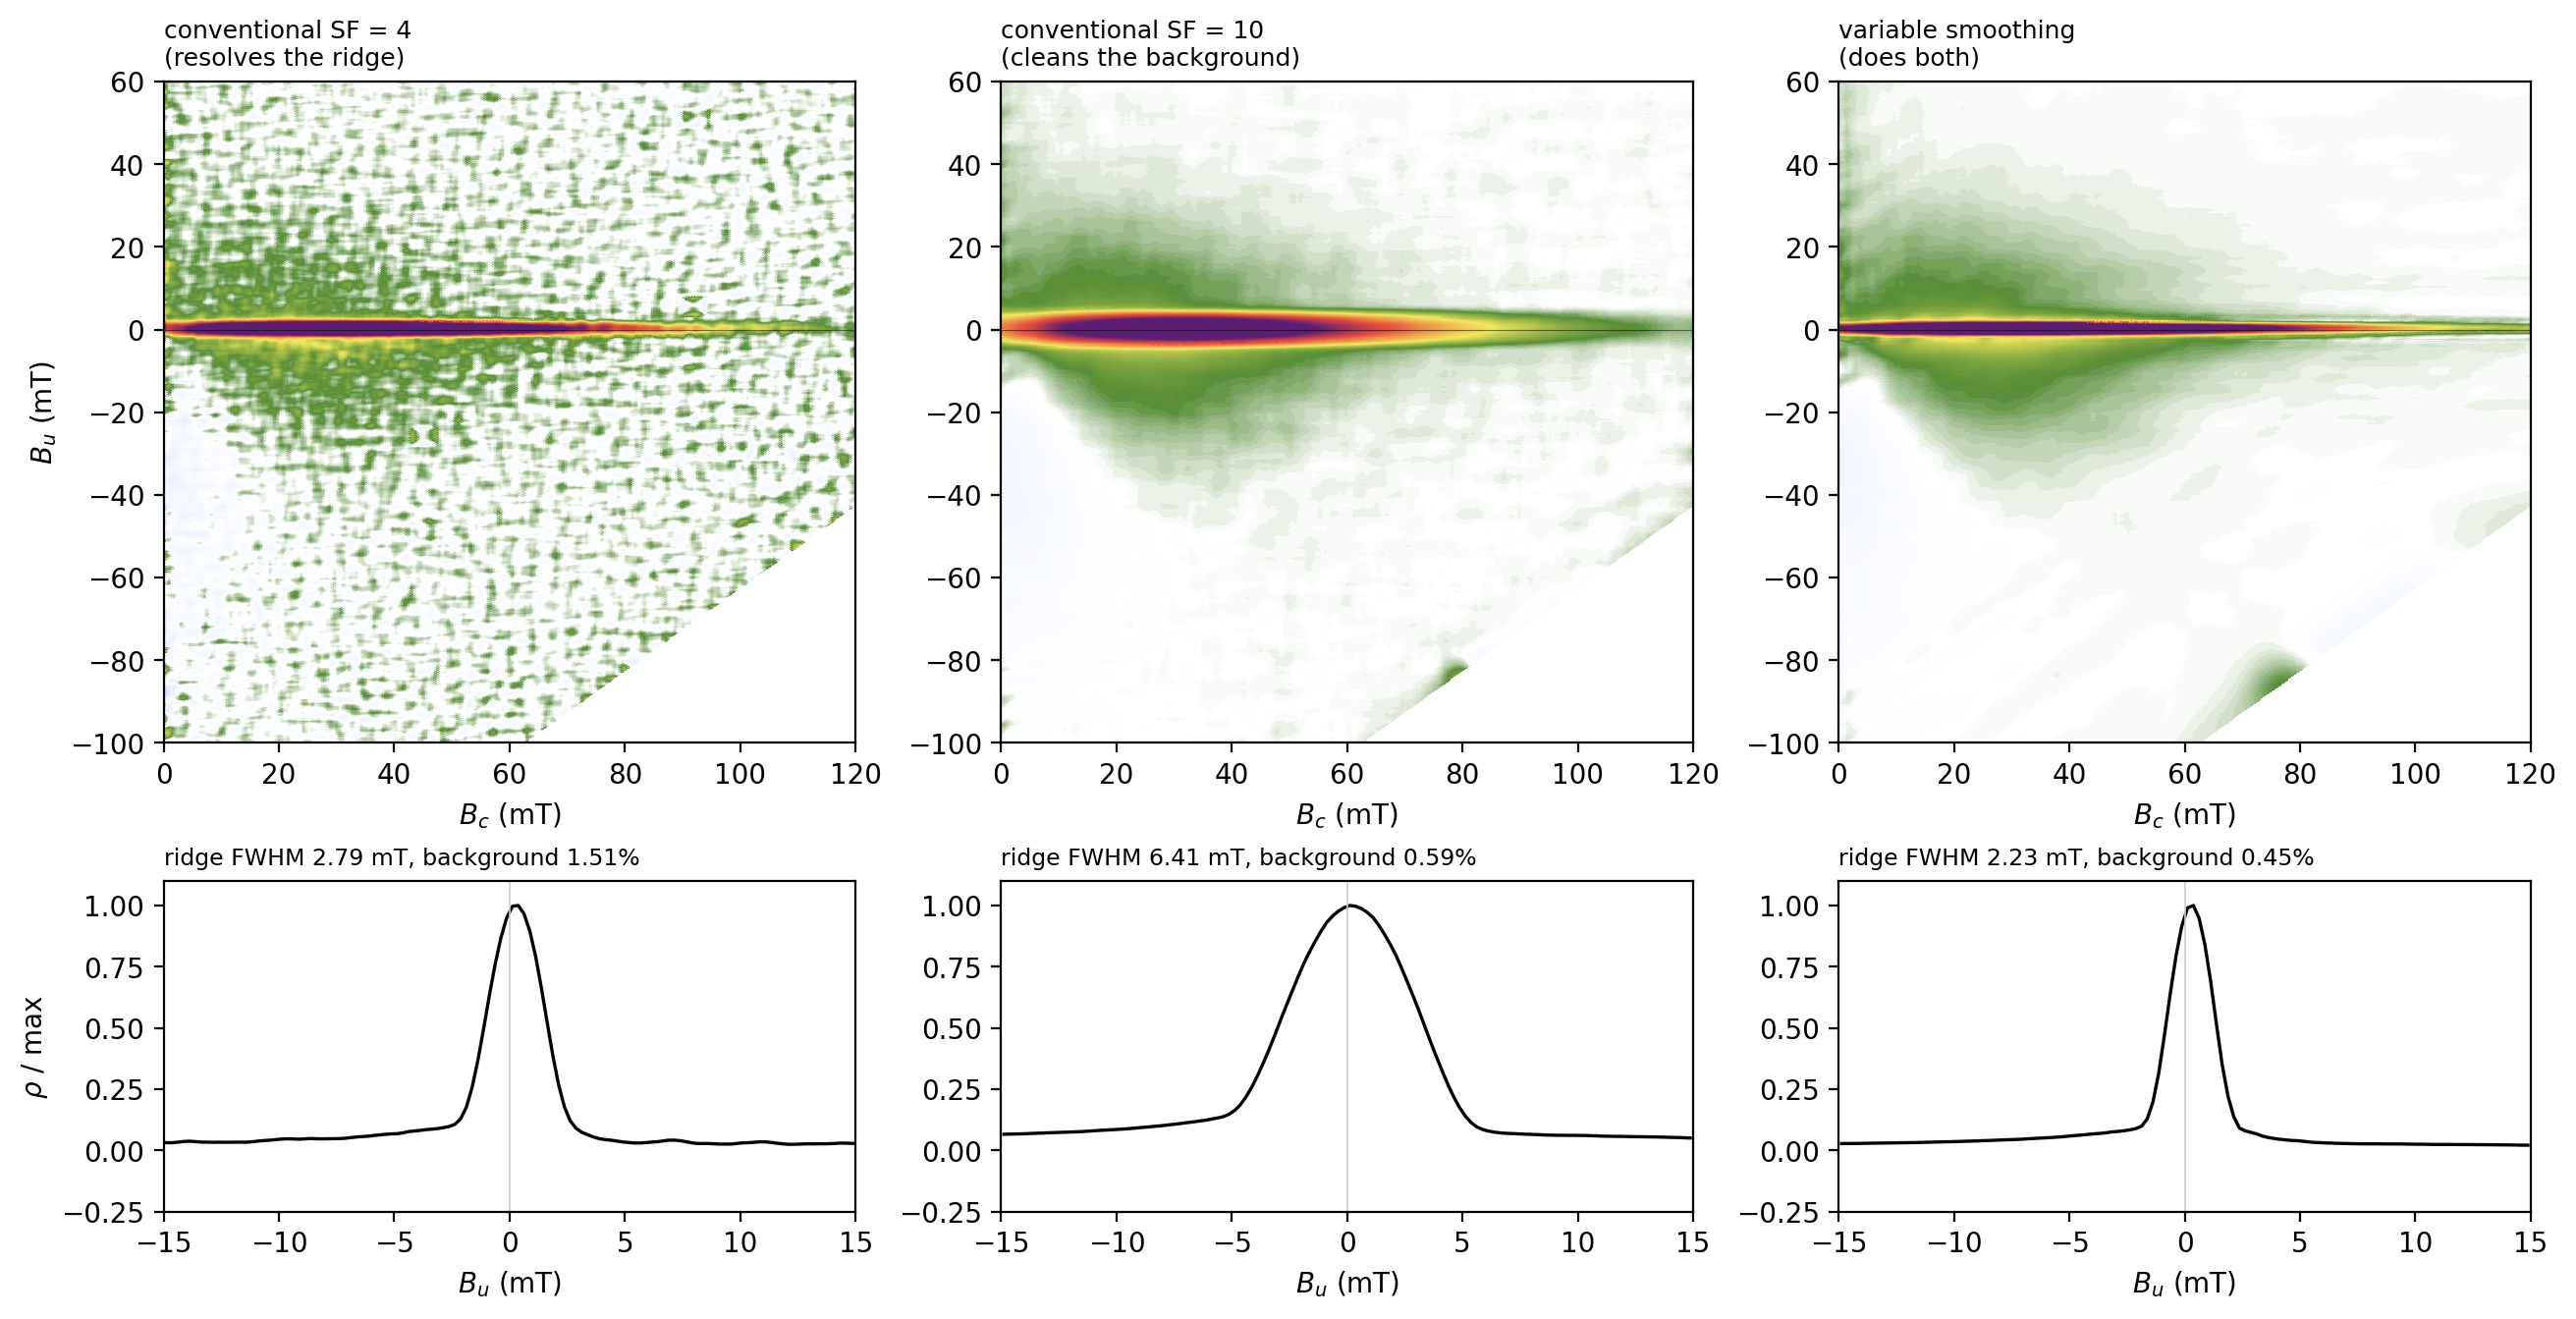

In [4]:
Ha, Hb = out['Ha_vals_used'], out['Hb_vals_used']
M = out['M_grid_used']
Bu, Bc = forc.bu_bc_from_ha_hb(Ha, Hb)
Ha_e, Hb_e = np.meshgrid(forc.centers_to_edges(Ha),
                         forc.centers_to_edges(Hb), indexing='ij')
Bc_e, Bu_e = 0.5 * (Hb_e - Ha_e), 0.5 * (Hb_e + Ha_e)
window = (Bc >= 0) & (Bc <= 0.12) & (Bu >= -0.10) & (Bu <= 0.06)

variants = [
    ('conventional SF = 4\n(resolves the ridge)',
     dict(sc0=5, sc1=5, sb0=5, sb1=5, lambda_c=0.0, lambda_b=0.0)),
    ('conventional SF = 10\n(cleans the background)',
     dict(sc0=11, sc1=11, sb0=11, sb1=11, lambda_c=0.0, lambda_b=0.0)),
    ('variable smoothing\n(does both)', settings),
]

fig, axes = plt.subplots(2, 3, figsize=(13, 6.6), constrained_layout=True,
                         height_ratios=[2, 1])
for k, (title, kw) in enumerate(variants):
    rho = forc.variforc_rho_from_grid(Ha, Hb, M, min_pts=8, **kw)
    vmax = np.nanpercentile(np.abs(rho[window & np.isfinite(rho)]), 99.0)

    ax = axes[0, k]
    ax.pcolormesh(1e3 * Bc_e, 1e3 * Bu_e, rho / vmax, cmap=forc.get_forc_cmap(2),
                  vmin=-1, vmax=1, shading='auto', rasterized=True)
    ax.set_xlim(0, 120); ax.set_ylim(-100, 60)
    ax.axhline(0, color='k', lw=0.4, alpha=0.5)
    ax.set_title(title, fontsize=9, loc='left')
    ax.set_xlabel(r'$B_c$ (mT)')
    if k == 0:
        ax.set_ylabel(r'$B_u$ (mT)')

    # vertical profile across the ridge
    band = (Bc > 0.02) & (Bc < 0.05) & (np.abs(Bu) < 0.015) & np.isfinite(rho)
    centres, profile = forc.bin_profile(Bu[band], rho[band], -0.015, 0.015,
                                        n_bins=120)
    peak = forc.profile_peak_and_fwhm(centres, profile, use_abs=False)
    background = (np.abs(Bu) > 0.03) & (Bc > 0.05) & (Bc < 0.10) & np.isfinite(rho)

    ax = axes[1, k]
    ax.plot(1e3 * centres, profile / np.nanmax(profile), 'k-', lw=1.2)
    ax.axvline(0, color='0.8', lw=0.6)
    ax.set_xlim(-15, 15); ax.set_ylim(-0.25, 1.1)
    ax.set_xlabel(r'$B_u$ (mT)')
    if k == 0:
        ax.set_ylabel(r'$\rho$ / max')
    ax.set_title(f"ridge FWHM {1e3 * peak['fwhm']:.2f} mT, "
                 f"background {np.nanstd(rho[background]) / np.nanmax(rho[window & np.isfinite(rho)]):.2%}",
                 fontsize=8.5, loc='left')
plt.show()

The two conventional panels show the trade-off directly: the small window keeps the
ridge narrow but leaves a speckled background, while the large window cleans the
background and roughly doubles the apparent ridge width. Variable smoothing gives the
narrowest ridge of the three *and* the quietest background, because it uses a different
window in each place.

That the ridge should be this narrow is the scientific point. Its width in B<sub>u</sub>
is what distinguishes non-interacting single-domain particles from a weakly interacting
assemblage, so a processing choice that broadens it changes the interpretation.

## 3. How the window varies

The smoothing factors are not free parameters chosen per cell; they follow Egli's rule,

$$s = \min\left[(1-\lambda)\,s_1 + \lambda\frac{|H|}{\delta H},\ \max\!\left(s_0, \frac{|H|}{\delta H}\right)\right]$$

The first term grows the window linearly away from the origin. The second holds it at a
floor across a ridge, then relaxes just fast enough that a window centred near the ridge
never reaches across it.

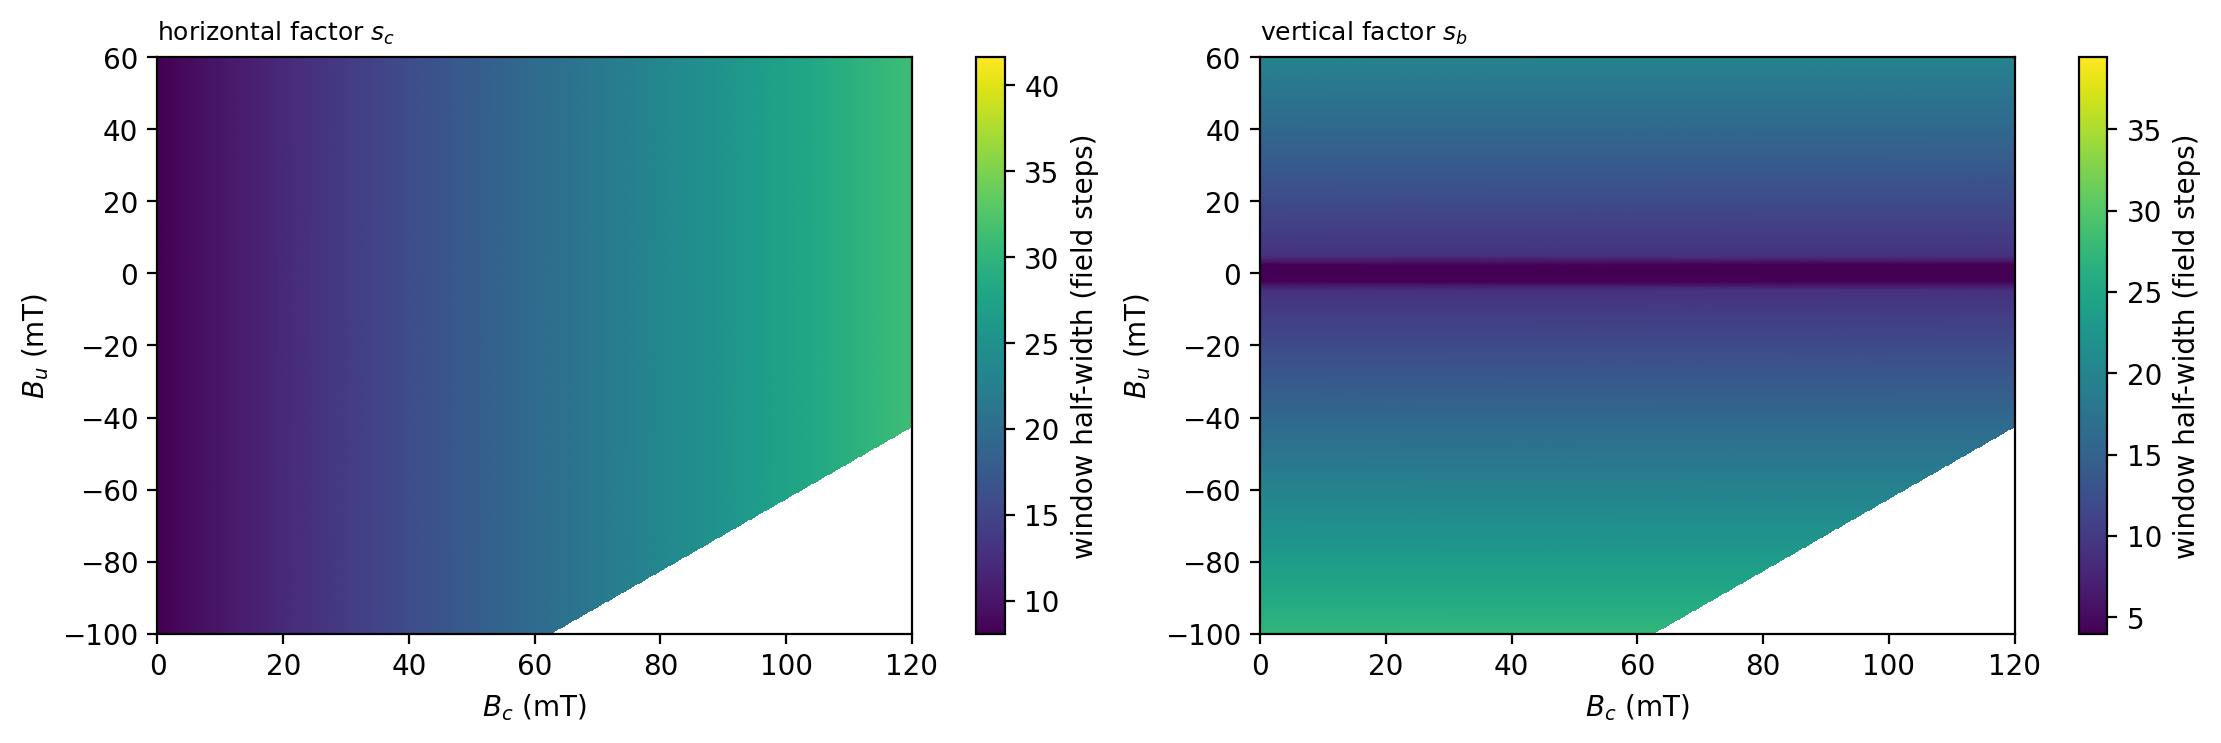

s_c ranges 8.1 to 41.6 field steps
s_b ranges 4.0 to 39.4 field steps
the narrow horizontal band in s_b is the central ridge, held at 4


In [5]:
result = forc.variforc_rho_from_grid(Ha, Hb, M, min_pts=8,
                                     return_factors=True, **settings)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), constrained_layout=True)
for ax, key, label in ((axes[0], 's_c', r'horizontal factor $s_c$'),
                       (axes[1], 's_b', r'vertical factor $s_b$')):
    mesh = ax.pcolormesh(1e3 * Bc_e, 1e3 * Bu_e, result[key], cmap='viridis',
                         shading='auto', rasterized=True)
    ax.set_xlim(0, 120); ax.set_ylim(-100, 60)
    ax.set_xlabel(r'$B_c$ (mT)')
    ax.set_ylabel(r'$B_u$ (mT)')
    ax.set_title(label, fontsize=9, loc='left')
    fig.colorbar(mesh, ax=ax, label='window half-width (field steps)')
plt.show()

print(f"s_c ranges {result['s_c'].min():.1f} to {result['s_c'].max():.1f} field steps")
print(f"s_b ranges {result['s_b'].min():.1f} to {result['s_b'].max():.1f} field steps")
print(f"the narrow horizontal band in s_b is the central ridge, held at "
      f"{settings['sb0']:g}")

The vertical factor is pinned to its floor in a narrow band along the ridge and grows
away from it; the horizontal factor grows steadily with coercivity. Away from the ridge
the window reaches several tens of field steps, which is why the background is so much
quieter than conventional processing at any factor small enough to keep the ridge sharp.

## 4. Which parts of the diagram the data support

Growing the window widens the region that is statistically significant, which is the other
half of Egli's argument. With `estimate_uncertainty=True` the measurement noise is
propagated through each local fit to a standard error on ρ, following Heslop and Roberts
(2012). The signal-to-noise ratio then says which features are real.

conventional SF = 4    noise 5.40e-11 A m$^2$, 50% of the plotted window has SNR > 3
variable smoothing     noise 5.40e-11 A m$^2$, 91% of the plotted window has SNR > 3


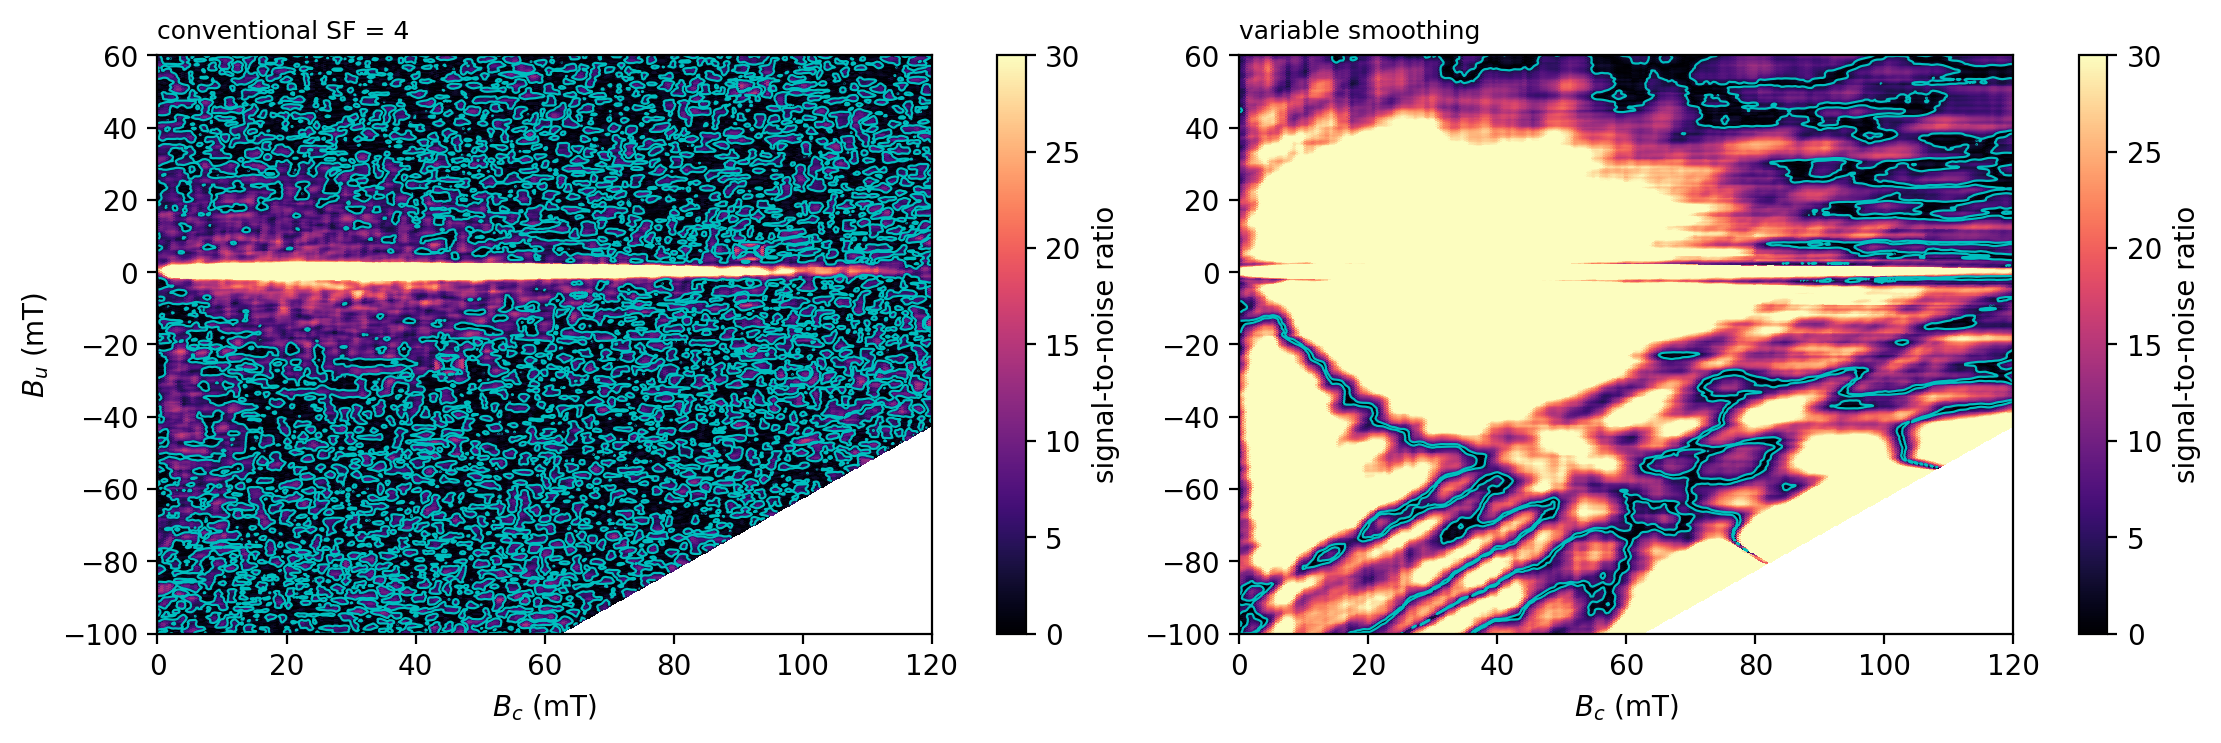

In [6]:
significance = {}
for label, s in (('conventional SF = 4',
                  dict(sc0=5, sc1=5, sb0=5, sb1=5, lambda_c=0.0, lambda_b=0.0)),
                 ('variable smoothing', settings)):
    res = forc.variforc_rho_from_grid(Ha, Hb, M, min_pts=8,
                                      estimate_uncertainty=True, **s)
    significance[label] = res

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), constrained_layout=True)
for ax, (label, res) in zip(axes, significance.items()):
    snr = res['snr']
    mesh = ax.pcolormesh(1e3 * Bc_e, 1e3 * Bu_e, snr, cmap='magma',
                         vmin=0, vmax=30, shading='auto', rasterized=True)
    ax.contour(1e3 * Bc, 1e3 * Bu, snr, levels=[3.0], colors='c', linewidths=0.8)
    ax.set_xlim(0, 120); ax.set_ylim(-100, 60)
    ax.set_xlabel(r'$B_c$ (mT)')
    ax.set_title(label, fontsize=9, loc='left')
    fig.colorbar(mesh, ax=ax, label='signal-to-noise ratio')
    inside = window & np.isfinite(snr)
    print(f"{label:22s} noise {res['noise']:.2e} A m$^2$, "
          f"{np.mean(snr[inside] > 3):.0%} of the plotted window has SNR > 3")
axes[0].set_ylabel(r'$B_u$ (mT)')
plt.show()

The cyan contour is the SNR = 3 significance threshold. Variable smoothing extends the
significant region over a much larger part of the diagram, so features in the background
can be interpreted rather than dismissed as noise. Egli treats SNR > 3 as the threshold
for a contribution being distinguishable from zero, and suggests contours are only worth
drawing where the SNR is comfortably above it.

## 5. Choosing parameters for your own sample

Four presets cover the cases Egli distinguishes, keyed to what a conventionally processed
diagram shows.

In [7]:
for name, meta in forc.VARIFORC_PRESETS.items():
    print(f"{name:16s} {meta['description']}")

regular          No sharp ridges: a smooth Preisach-type distribution.
central_ridge    A horizontal ridge along Bu = 0, the signature of non-interacting single-domain particles such as magnetofossils.
vertical_ridge   A vertical ridge along Bc = 0, produced by thermal relaxation in superparamagnetic assemblages.
both_ridges      Both a central and a vertical ridge over a continuous background, as in many volcanic ash and pseudo-single-domain samples.


Two numbers then matter:

- **`smoothing_factor`** sets the baseline window away from any ridge. Egli's published
  analyses use 7 to 11. Larger suppresses more noise.
- **`growth_rate`** sets how fast the window grows with distance from the origin. Between
  about 0.06 and 0.12 is sensible; 0 reproduces conventional processing. Above roughly 0.2
  the windows become large enough to create their own artefacts, which is what the
  diagonal limits in section 6 exist to control.

The practical recipe is unchanged from conventional processing: compute at several
settings, keep the features that persist, and report what you used.

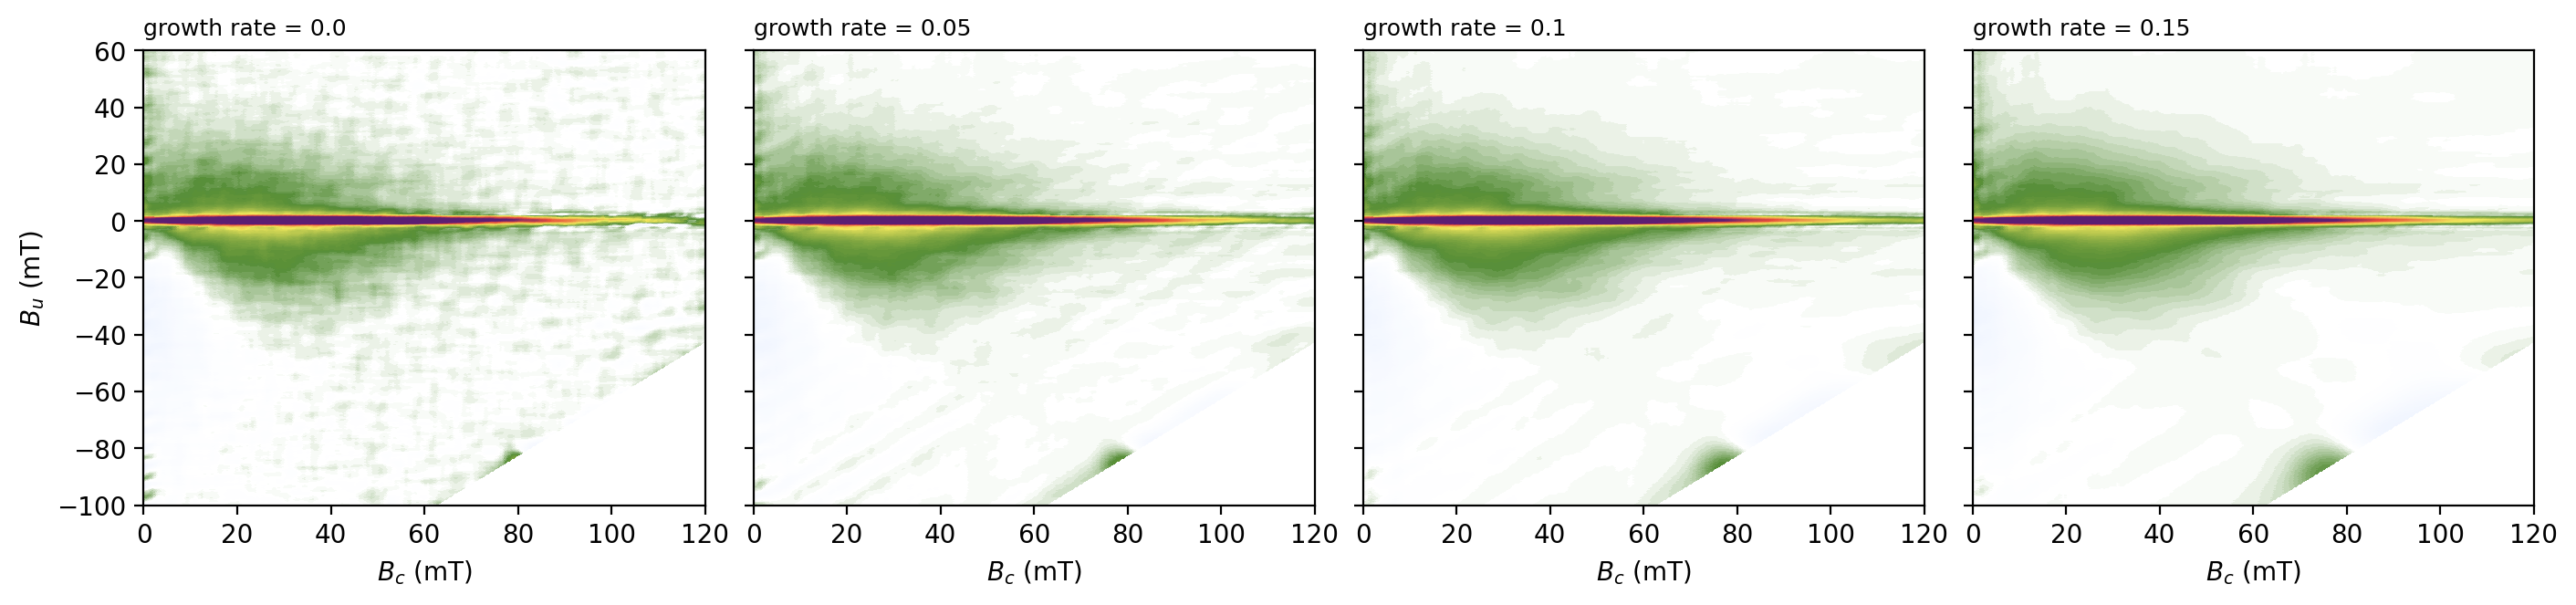

In [8]:
fig, axes = plt.subplots(1, 4, figsize=(14, 3.2), constrained_layout=True, sharey=True)
for ax, growth in zip(axes, (0.0, 0.05, 0.10, 0.15)):
    trial = forc.variforc_settings('central_ridge', smoothing_factor=9,
                                   growth_rate=growth, central_ridge=4,
                                   central_ridge_position=0.0004)
    rho = forc.variforc_rho_from_grid(Ha, Hb, M, min_pts=8, **trial)
    vmax = np.nanpercentile(np.abs(rho[window & np.isfinite(rho)]), 99.0)
    ax.pcolormesh(1e3 * Bc_e, 1e3 * Bu_e, rho / vmax, cmap=forc.get_forc_cmap(2),
                  vmin=-1, vmax=1, shading='auto', rasterized=True)
    ax.set_xlim(0, 120); ax.set_ylim(-100, 60)
    ax.set_xlabel(r'$B_c$ (mT)')
    ax.set_title(f'growth rate = {growth}', fontsize=9, loc='left')
axes[0].set_ylabel(r'$B_u$ (mT)')
plt.show()

## 6. Diagonal artefacts

Large regression windows misfit where the measured curves change most sharply: where the
curves are steepest, and where consecutive curves differ most. In FORC coordinates those
conditions fall along the two diagonals through the coercive field, and a window spanning
them produces ridge-like artefacts that are not features of the sample.

Egli's remedy is not to shrink the window, which would trade one artefact for another, but
to **truncate its corners** along 45° lines so that the rectangle becomes an octagon narrow
enough in the diagonal direction while keeping its resolution along B<sub>c</sub> and
B<sub>u</sub>.

Cultured magnetotactic bacteria have a near-rectangular hysteresis loop and show the
problem clearly.

estimated coercive field: 37.7 mT


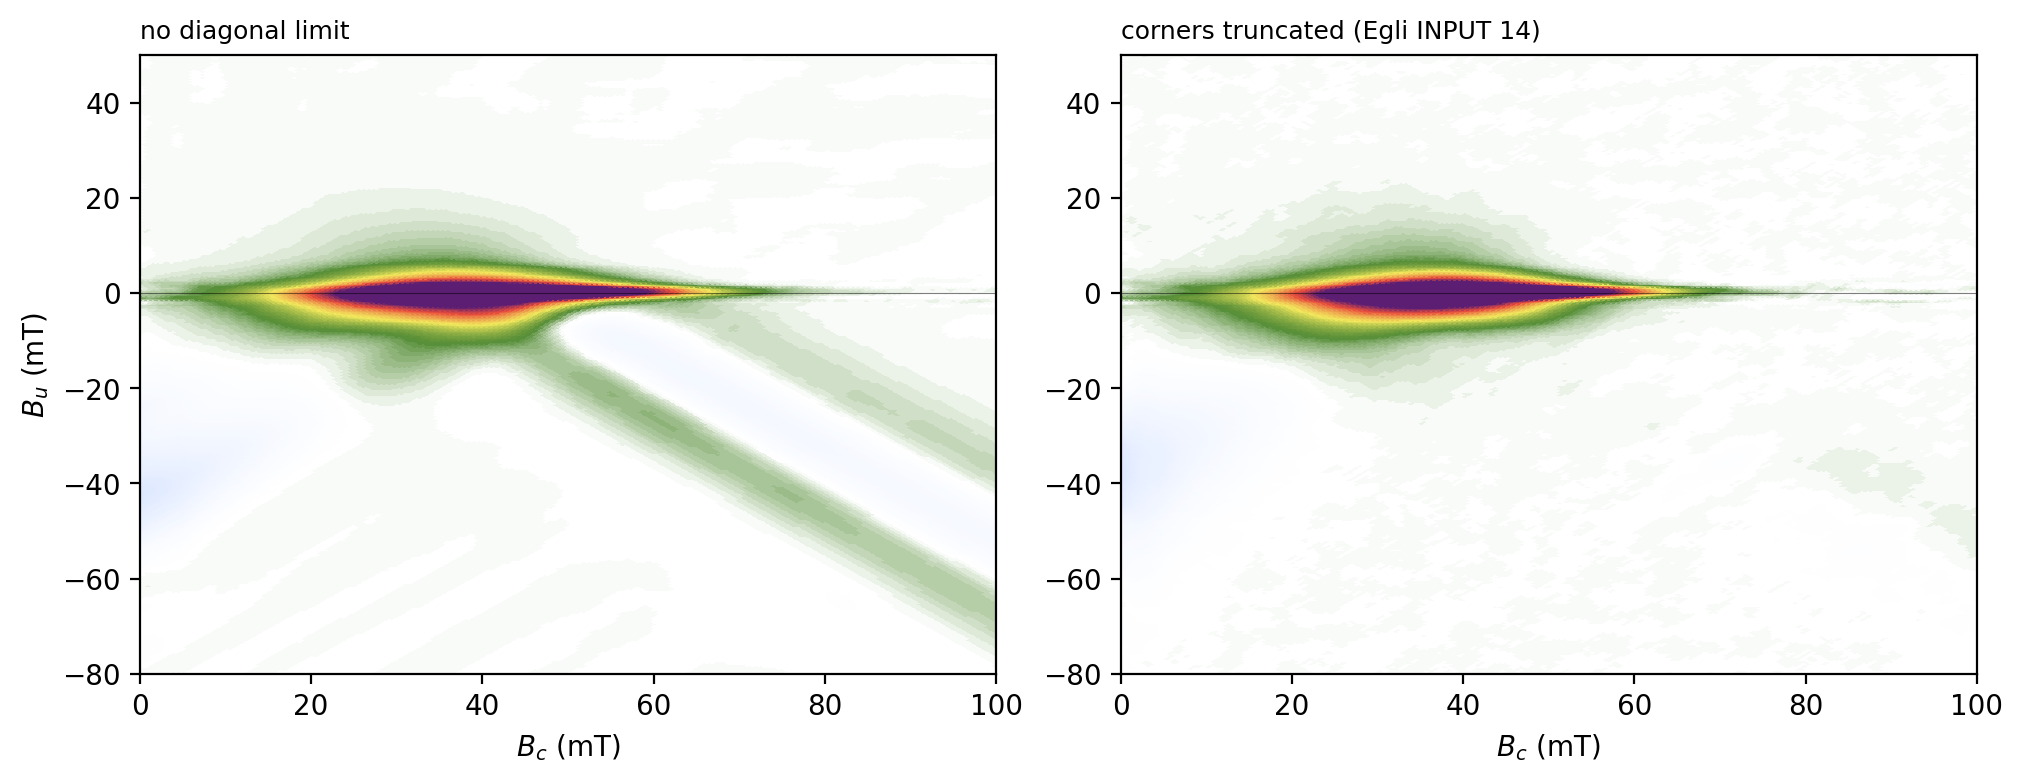

In [9]:
bacteria = '../example_data/FORC/variforc_examples/magnetotactic_MV1.txt'
segs, _ = forc.phase1_prepare_segments_dual(bacteria, export_magic=False, verbose=False)
curves = [s for s in segs if s.kind == 'forc']
step = forc.infer_B_step_from_forcs(curves)
curves = forc.regrid_forcs_in_hysteresis_space(curves, B_step=step, verbose=False)
Ha2, Hb2, M2, _, _ = forc.build_forc_grid(curves, verbose=False)
Bu2, Bc2 = forc.bu_bc_from_ha_hb(Ha2, Hb2)
Ha2_e, Hb2_e = np.meshgrid(forc.centers_to_edges(Ha2),
                           forc.centers_to_edges(Hb2), indexing='ij')
Bc2_e, Bu2_e = 0.5 * (Hb2_e - Ha2_e), 0.5 * (Hb2_e + Ha2_e)
win2 = (Bc2 >= 0) & (Bc2 <= 0.10) & (Bu2 >= -0.08) & (Bu2 <= 0.05)

print(f"estimated coercive field: {1e3 * forc.find_coercive_field(Ha2, Hb2, M2):.1f} mT")

base = dict(sc0=9, sc1=9, sb0=3, sb1=9, lambda_c=0.1, lambda_b=0.1,
            ridge_limits=[('Bu', 0.0003, 3, 0.0004)])
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8), constrained_layout=True)
for ax, (title, extra) in zip(axes, [
        ('no diagonal limit', {}),
        ('corners truncated (Egli INPUT 14)',
         dict(diagonal_limits={'mode': 'automatic', 'limit': 9.0, 'width': None}))]):
    rho = forc.variforc_rho_from_grid(Ha2, Hb2, M2, min_pts=8, **base, **extra)
    vmax = np.nanpercentile(np.abs(rho[win2 & np.isfinite(rho)]), 99.0)
    ax.pcolormesh(1e3 * Bc2_e, 1e3 * Bu2_e, rho / vmax, cmap=forc.get_forc_cmap(2),
                  vmin=-1, vmax=1, shading='auto', rasterized=True)
    ax.set_xlim(0, 100); ax.set_ylim(-80, 50)
    ax.axhline(0, color='k', lw=0.4, alpha=0.5)
    ax.set_xlabel(r'$B_c$ (mT)')
    ax.set_title(title, fontsize=9, loc='left')
axes[0].set_ylabel(r'$B_u$ (mT)')
plt.show()

In the `variforc_settings` interface the same thing is requested with a single
`diagonal_limit` argument, which places the truncation automatically at the coercive field
estimated from the measurements.

## 7. Fidelity to the published algorithm

The implementation here is independent: it was written from the equations in Egli (2013)
and the parameter semantics documented in the VARIFORC manual, not from the VARIFORC
source, which is separately licensed.

The strongest available check is one Egli states quantitatively. His Eq. 7 defines a
synthetic magnetization surface, `M = -4|B_u|`, that is not physical but produces the
*unit ridge* ρ = δ(B<sub>u</sub>) exactly. His Eq. 9 then predicts the width of that ridge
after processing: ΔH<sub>b</sub> = (1.076 s<sub>b</sub> − 0.468) δH. Reproducing that
relation without having been fitted to it tests the weight function, the rectangle
geometry and the coefficient extraction together.

In [10]:
dH = 0.001
Ha_r = np.arange(-0.20, 0.05 + dH / 2, dH)
Hb_r = np.arange(-0.20, 0.20 + dH / 2, dH)
A, B = np.meshgrid(Ha_r, Hb_r, indexing='ij')
ideal = -4.0 * np.abs(0.5 * (B + A))
ideal[B < A] = np.nan
Bu_r, Bc_r = forc.bu_bc_from_ha_hb(Ha_r, Hb_r)

print(f"{'s_b':>5} {'measured FWHM/dH':>18} {'Egli Eq. 9':>12} {'difference':>12}")
for sb in (2.0, 3.0, 5.0, 8.0, 10.0):
    rho = forc.variforc_rho_from_grid(Ha_r, Hb_r, ideal, sc0=6, sc1=6,
                                      sb0=sb, sb1=sb, lambda_c=0.0,
                                      lambda_b=0.0, dH=dH, min_pts=8)
    band = (Bc_r > 0.04) & (Bc_r < 0.06) & (np.abs(Bu_r) < 0.03) & np.isfinite(rho)
    centres, profile = forc.bin_profile(Bu_r[band], rho[band], -0.03, 0.03,
                                        n_bins=240)
    measured = forc.profile_peak_and_fwhm(centres, profile,
                                          use_abs=False)['fwhm'] / dH
    predicted = 1.076 * sb - 0.468
    print(f"{sb:5.1f} {measured:18.3f} {predicted:12.3f} "
          f"{100 * (measured - predicted) / predicted:11.1f}%")

  s_b   measured FWHM/dH   Egli Eq. 9   difference
  2.0              1.678        1.684        -0.4%
  3.0              2.746        2.760        -0.5%
  5.0              4.898        4.912        -0.3%


  8.0              8.134        8.140        -0.1%
 10.0             10.295       10.292         0.0%


The measured relation is within about half a percent of the published one across the
range. Alongside this, the test suite checks the estimator against an analytic quadratic
surface (agreeing with the independent mixed-derivative estimator to 5 × 10⁻¹¹), against a
Preisach assemblage with a closed-form distribution, and confirms that the propagated
uncertainty matches the scatter of ρ over independent noise realizations.

Further detail, including the differences that remain from VARIFORC, is in
[forc_implementation_notes.md](./forc_implementation_notes.md).

## Summary

- Variable smoothing lets the regression window grow where the FORC function is genuinely
  smooth and holds it narrow across ridges, giving a sharper ridge *and* a quieter
  background than any single window achieves.
- Describe the sample with `variforc_settings` and a preset; set `smoothing_factor` and
  `growth_rate`, and report both with any diagram.
- Turn on `estimate_uncertainty` to see which parts of the diagram the data support. SNR
  > 3 is the conventional significance threshold.
- Use a diagonal limit for samples with near-rectangular loops, where large windows would
  otherwise smear artefacts along the coercive-field diagonals.
- Variable smoothing earns its cost on noisy data. On very clean measurements a
  well-chosen constant window does just as well.

## References

- Egli, R., Chen, A. P., Winklhofer, M., Kodama, K. P., & Horng, C.-S. (2010). Detection of noninteracting single domain particles using first-order reversal curve diagrams. *Geochemistry, Geophysics, Geosystems*, 11, Q01Z11. https://doi.org/10.1029/2009GC002916
- Egli, R. (2013). VARIFORC: An optimized protocol for calculating non-regular first-order reversal curve (FORC) diagrams. *Global and Planetary Change*, 110, 302–320. https://doi.org/10.1016/j.gloplacha.2013.08.003
- Harrison, R. J., & Feinberg, J. M. (2008). FORCinel: An improved algorithm for calculating first-order reversal curve distributions using locally weighted regression smoothing. *Geochemistry, Geophysics, Geosystems*, 9, Q05016. https://doi.org/10.1029/2008GC001987
- Heslop, D., & Roberts, A. P. (2012). Estimation of significance levels and confidence intervals for first-order reversal curve distributions. *Geochemistry, Geophysics, Geosystems*, 13, Q12Z40. https://doi.org/10.1029/2012GC004115
- Ludwig, P., Egli, R., Bishop, S., Chernenko, V., Frederichs, T., Rugel, G., Merchel, S., & Orgeira, M. J. (2013). Characterization of primary and secondary magnetite in marine sediment by combining chemical and magnetic unmixing techniques. *Global and Planetary Change*, 110, 321–339. https://doi.org/10.1016/j.gloplacha.2013.08.018
- Pike, C. R., Roberts, A. P., & Verosub, K. L. (1999). Characterizing interactions in fine magnetic particle systems using first order reversal curves. *Journal of Applied Physics*, 85, 6660–6667. https://doi.org/10.1063/1.370176